In [1]:
from sklearn.datasets import load_digits
import pandas as pd

digits = load_digits()

df = pd.DataFrame(digits.data)
df['label'] = digits.target

Datasetet består av cirka 1800 lågupplösta bilder (8×8 pixlar) av handskrivna siffror. Varje bild representeras som 64 pixelvärden, och bilder av samma siffra varierar något i utseende men delar gemensamma mönster.

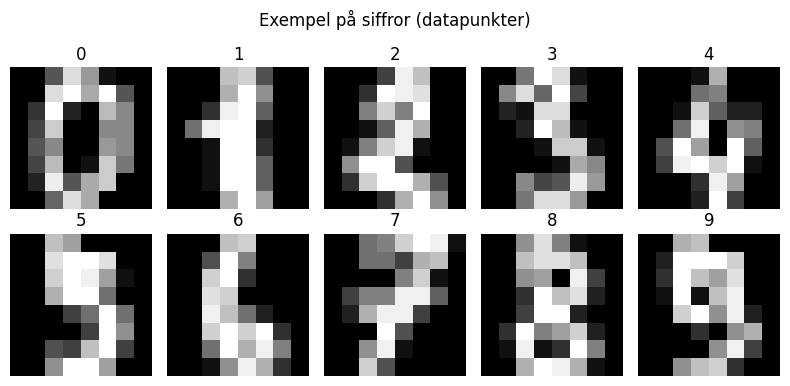

In [24]:
import numpy as np
import matplotlib.pyplot as plt

X = df.drop(columns='label').values
y = df['label'].values

plt.figure(figsize=(8, 4))

for digit in range(10):
    idx = np.where(y == digit)[0][0]  # första förekomsten
    
    plt.subplot(2, 5, digit + 1)
    plt.imshow(X[idx].reshape(8, 8), cmap='gray')
    plt.title(str(digit))
    plt.axis('off')

plt.suptitle("Exempel på siffror (datapunkter)")
plt.tight_layout()
plt.show()

Här ser vi exempel på datapunkter i datan. Varje bild består av 64 pixlar, vilket innebär att varje siffra representeras som en punkt i ett 64-dimensionellt rum.

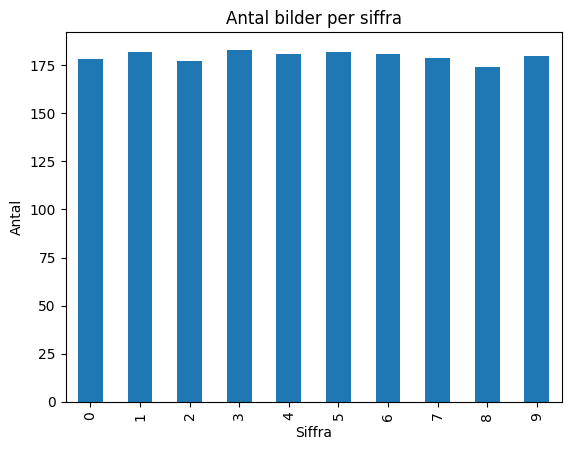

In [25]:
df['label'].value_counts().sort_index().plot(kind='bar')
plt.title("Antal bilder per siffra")
plt.xlabel("Siffra")
plt.ylabel("Antal")
plt.show()

In [3]:
import numpy as np

pixel_variation = np.var(df.drop(columns='label'), axis=0)

Jag försöker förstå variationens betydelse i data och varför vi vill använda datareduktion. Jag vill hitta en pixel i datan som har hög variation över de olika bilderna, och en utan variation alls.

In [20]:
pixel_var = df.drop(columns="label").var()

low_var_pixel = pixel_var.idxmin()
high_var_pixel = pixel_var.idxmax()

low_var_pixel, high_var_pixel

(0, 42)

In [21]:
print("Låg variation pixel:", low_var_pixel, "varians:", pixel_var[low_var_pixel])
print("Hög variation pixel:", high_var_pixel, "varians:", pixel_var[high_var_pixel])

Låg variation pixel: 0 varians: 0.0
Hög variation pixel: 42 varians: 42.74485129261464


Två pixlar i datan där variansen skiljer sig väldigt mycket. Visualiserar variationen med en boxplot.

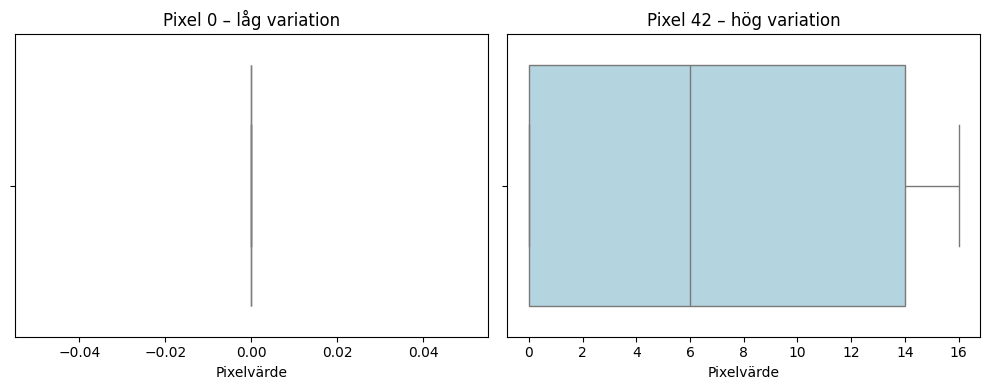

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.boxplot(x=df[low_var_pixel], ax=axes[0], color="lightgray")
axes[0].set_title(f"Pixel {low_var_pixel} – låg variation")
axes[0].set_xlabel("Pixelvärde")

sns.boxplot(x=df[high_var_pixel], ax=axes[1], color="lightblue")
axes[1].set_title(f"Pixel {high_var_pixel} – hög variation")
axes[1].set_xlabel("Pixelvärde")

plt.tight_layout()
plt.show()

Här ser vi två pixlar. Den vänstra varierar nästan inte alls och är därför nästan alltid irrelevant för att skilja siffror åt. Den högra varierar mycket mer mellan bilder och innehåller därför information. Det är den typen av variation vi vill bevara när vi reducerar dimensioner.

Pixlar med låg variation förändras nästan inte alls mellan bilder och bidrar därför med väldigt lite information. Pixlar med hög variation förändras mer mellan bilder och hjälper oss skilja olika siffror åt.


In [13]:
mean_a = Xa.mean(axis=0)
mean_b = Xb.mean(axis=0)

In [15]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

X = df.drop(columns='label').values

X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

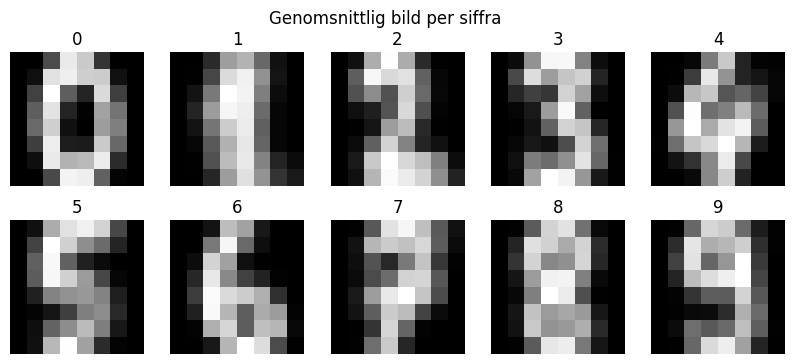

In [19]:
import matplotlib.pyplot as plt
import numpy as np

X = df.drop(columns='label').values
y = df['label'].values

plt.figure(figsize=(10,4))

for digit in range(10):
    mean_img = X[y == digit].mean(axis=0)
    
    plt.subplot(2,5,digit+1)
    plt.imshow(mean_img.reshape(8,8), cmap='gray')
    plt.title(f"{digit}")
    plt.axis('off')

plt.suptitle("Genomsnittlig bild per siffra")
plt.show()

Detta är genomsnittliga bilder per klass, där varje pixel representerar medelvärdet av alla observationer för den siffran. Eftersom datan representerar pixlar kan vi direkt visualisera variablerna som bilder.